In [230]:
import pandas as pd
import numpy as np
import yfinance as yf
import ta

In [231]:
df = yf.download('INRUSD=X', period= '1y')

[*********************100%%**********************]  1 of 1 completed


In [232]:
df['%K'] = ta.momentum.stoch(df.High, df.Low, df.Close, window=14, smooth_window=3)

In [233]:
df['%D'] = df['%K'].rolling(3).mean()

In [234]:

df['rsi'] = ta.momentum.rsi(df['Close'], window=14)

In [235]:
df['macd'] = ta.trend.macd_diff(df.Close)

In [236]:
df.dropna(inplace=True)

In [237]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,%K,%D,rsi,macd
Date,,,,,,,,,,
2023-10-02,0.012043,0.012061,0.012007,0.012043,0.012043,0,54.702069,37.484995,50.625079,-8.383317e-07
2023-10-03,0.011996,0.012029,0.011996,0.011996,0.011996,0,6.347530,30.712697,41.029206,-2.788231e-06
2023-10-04,0.012015,0.012022,0.012000,0.012015,0.012015,0,25.608105,28.885901,45.463483,-2.621066e-06
2023-10-05,0.011983,0.012021,0.011807,0.011983,0.011983,0,62.957634,31.637756,39.974332,-4.343279e-06
2023-10-06,0.012016,0.012036,0.011999,0.012016,0.012016,0,74.511381,54.359040,47.017348,-3.061490e-06


In [238]:
dfx = pd.DataFrame()
for i in range(1, 4):
    mask = (df['%K'].shift(i) < 20) & (df['%D'].shift(i) < 20)
    dfxn = pd.DataFrame([mask])
    dfx = pd.concat([dfx, dfxn], ignore_index=True)

In [239]:
dfx

Date,2023-10-02,2023-10-03,2023-10-04,2023-10-05,2023-10-06,2023-10-09,2023-10-10,2023-10-11,2023-10-12,2023-10-13,...,2024-08-06,2024-08-07,2024-08-08,2024-08-09,2024-08-12,2024-08-13,2024-08-14,2024-08-15,2024-08-16,2024-08-17
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [240]:
dfx.sum(axis=0)

Date
2023-10-02    0
2023-10-03    0
2023-10-04    0
2023-10-05    0
2023-10-06    0
             ..
2024-08-13    0
2024-08-14    0
2024-08-15    0
2024-08-16    0
2024-08-17    0
Length: 230, dtype: int64

In [241]:
def gettrigger(df, lags, buy = True):
    dfx = pd.DataFrame()
    for i in range(1, lags+1):
        if buy:
            mask = (df['%K'].shift(i) < 20) & (df['%D'].shift(i) < 20)
        else:
            mask = (df['%K'].shift(i) > 80) & (df['%D'].shift(i) > 80)
        dfxn = pd.DataFrame([mask])
        dfx = pd.concat([dfx, dfxn], ignore_index=True)
    return dfx.sum(axis=0)

In [242]:
gettrigger(df, 4)

Date
2023-10-02    0
2023-10-03    0
2023-10-04    0
2023-10-05    0
2023-10-06    0
             ..
2024-08-13    0
2024-08-14    0
2024-08-15    0
2024-08-16    0
2024-08-17    0
Length: 230, dtype: int64

In [243]:
df['Buytrigger'] = np.where(gettrigger(df, 4), 1, 0)

In [244]:
df['Selltrigger'] = np.where(gettrigger(df, 4, False), 1, 0)

In [245]:
df['Buy'] = np.where((df.Buytrigger) & 
                     (df['%K'].between(20,80) & (df['%D'].between(20,80)) & (df.rsi > 50) &
                      (df.macd > 0)),1,0)


In [246]:
df['Sell'] = np.where((df.Selltrigger) & 
                     (df['%K'].between(20,80) & (df['%D'].between(20,80)) & (df.rsi < 50) &
                      (df.macd < 0)),1,0)

In [247]:
Buying_dates, Selling_dates = [], []


In [248]:
for i in range(len(df)-1):
    if df.Buy.iloc[i]:
        Buying_dates.append(df.iloc[i+1].name)
        for num, j in enumerate(df.Sell[i:]):
            if j:
                Selling_dates.append(df.iloc[i+num+1].name)
                break

In [249]:
cutif = len(Buying_dates) - len(Selling_dates)

if cutif:
    Buying_dates =  Buying_dates[:-cutif]

In [250]:
frame = pd.DataFrame({'Buying_Dates': Buying_dates, 'Selling_Dates': Selling_dates})

In [251]:
frame

,Buying_Dates,Selling_Dates


In [252]:
actual = frame[frame.Buying_Dates >  frame.Selling_Dates.shift(1)]

In [253]:
actual

,Buying_Dates,Selling_Dates


In [254]:
def profitable():
    Buyprice = df.loc[actual.Buying_Dates].Open
    Sellprice = df.loc[actual.Selling_Dates].Open

    return (Sellprice.values - Buyprice.values)/Buyprice.values



In [255]:
profit = profitable()

In [256]:
profit

array([], dtype=float64)

In [257]:
profit.mean()

C:\Users\Amit.Ranjan\AppData\Local\Temp\ipykernel_52512\2214532109.py:1: RuntimeWarning: Mean of empty slice.
  profit.mean()
d:\Desktop Backup\Python_Practice\Project13\.venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


np.float64(nan)

In [258]:
(profit + 1).prod()

np.float64(1.0)

In [259]:
import matplotlib.pyplot as plt

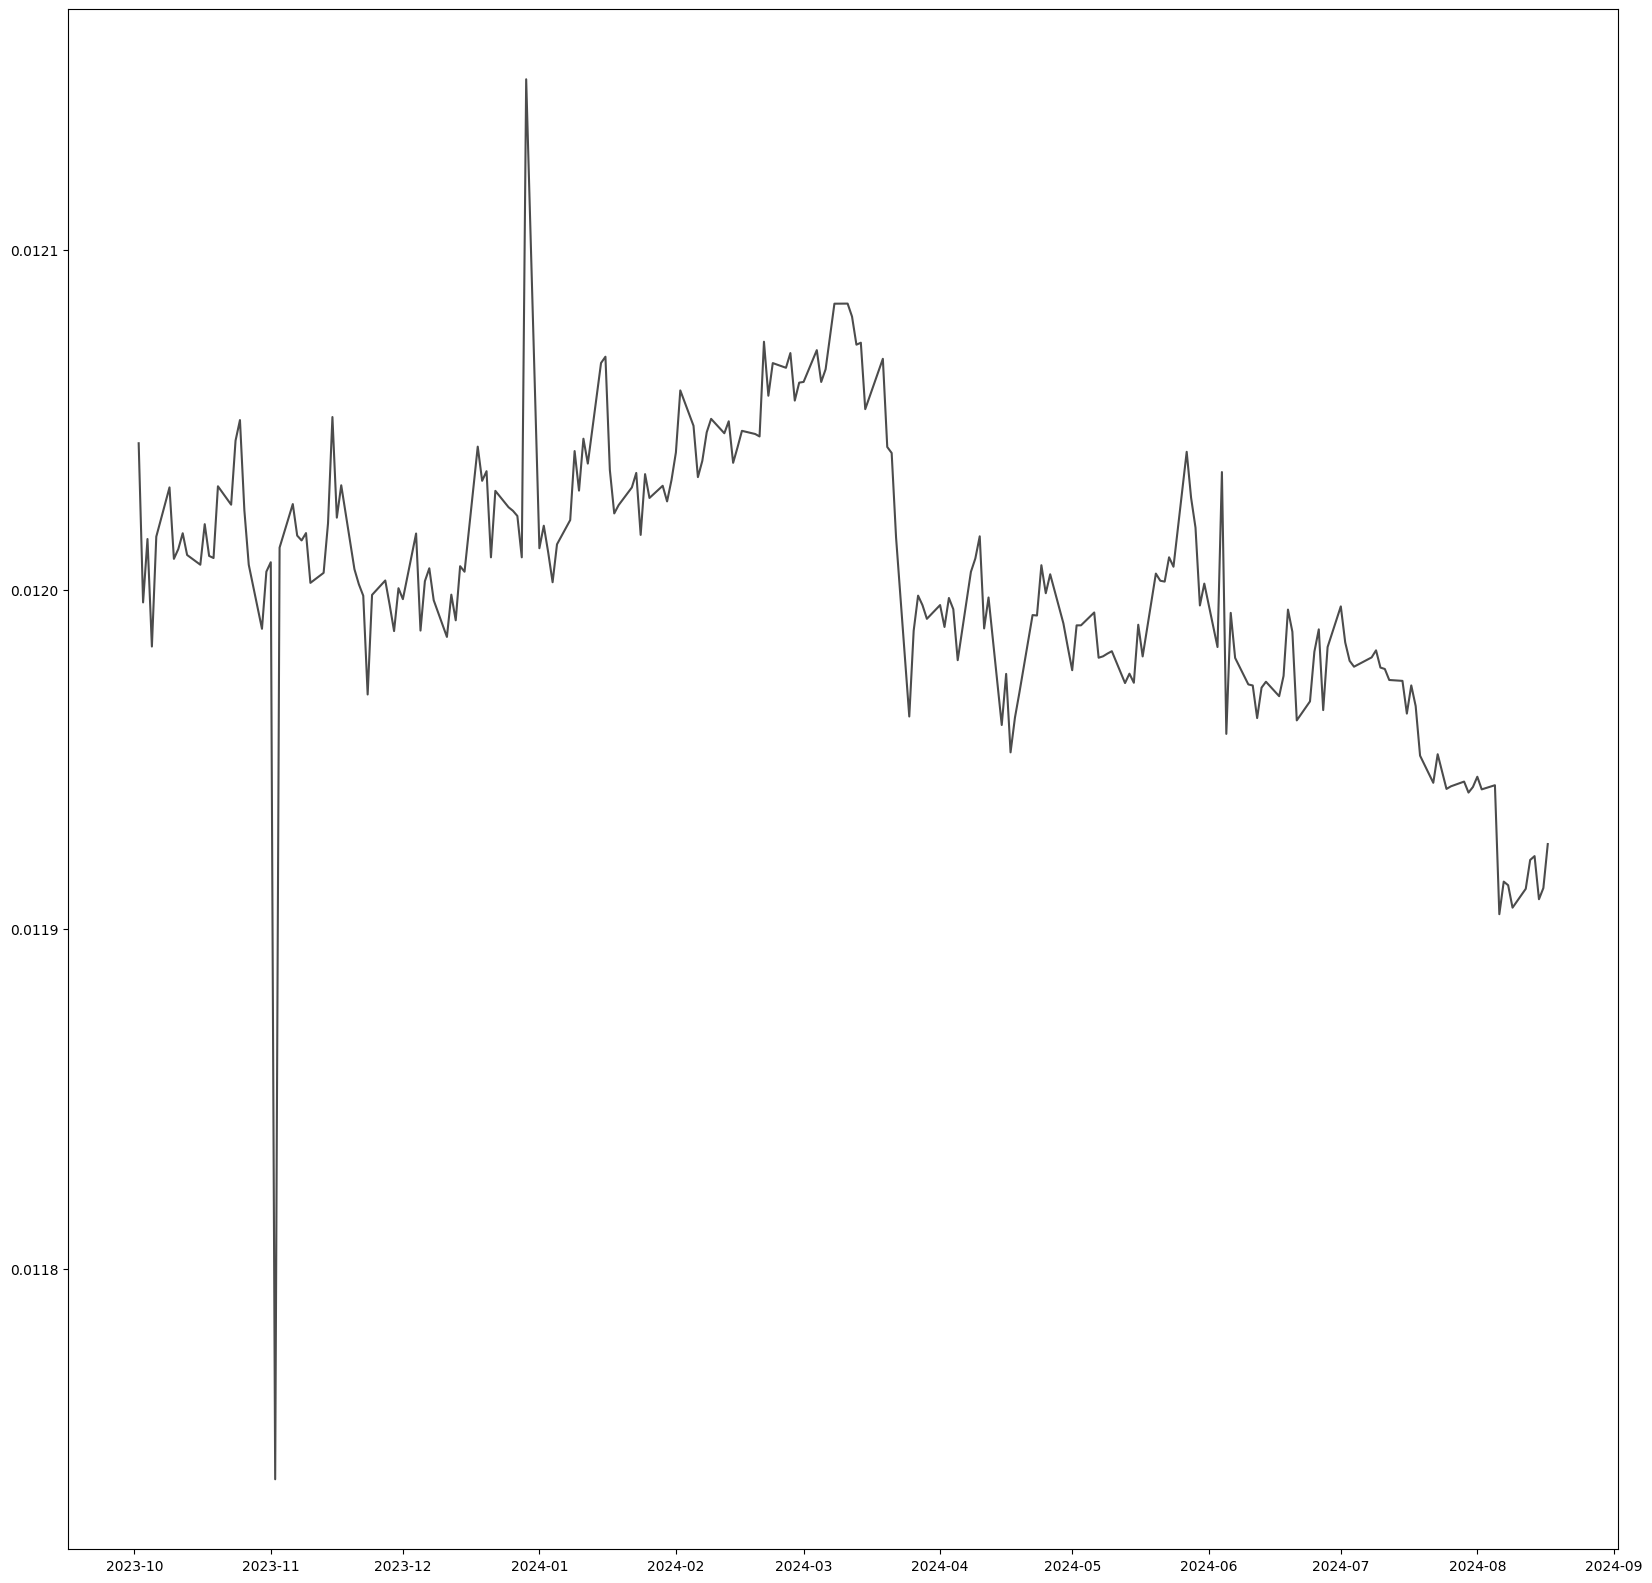

In [260]:

plt.figure(figsize = (20,20))
plt.plot(df.Close, color = 'k', alpha = 0.7)
plt.scatter(actual['Buying_Dates'], df.Open[actual['Buying_Dates']], marker="^", color = 'g', s = 500)
plt.scatter(actual['Selling_Dates'], df.Open[actual['Selling_Dates']], marker="v", color = 'r', s = 500)